# 3장 실습
----

In [1]:
import pandas as pd
import sklearn
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import platform
import matplotlib.pyplot as plt
from matplotlib import rc

os_name = platform.system()

if os_name == "Windows":
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="AppleGothic")

# 수학용 마이너스 대신 일반 하이픈 사용
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Malgun Gothic", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "mathtext.fontset": "dejavusans",
})

sklearn.set_config(display='text')

df = pd.read_csv('student-por.csv')

X = df[['failures', 'goout', 'health']]
y = df['G3']

ridge = Ridge(alpha=0)
ridge.fit(X=X, y=y)

print(ridge.coef_, ridge.intercept_)

[-2.10765672 -0.19660247 -0.19256291] 13.680757699345355


In [2]:
poly = PolynomialFeatures(degree=2, include_bias=False)

poly.fit(X=X)
X_poly = poly.transform(X=X)

X_poly.shape

ss = StandardScaler()
X_poly_scaled = ss.fit_transform(X_poly)

print(X_poly.shape, X_poly_scaled)

(649, 9) [[-0.37430512  0.69378496 -0.3710422  ...  0.58782199  0.11749022
  -0.59976447]
 [-0.37430512 -0.15738033 -0.3710422  ... -0.33144662 -0.34370626
  -0.59976447]
 [-0.37430512 -1.00854562 -0.3710422  ... -0.98806706 -0.80490273
  -0.59976447]
 ...
 [-0.37430512 -1.85971092  1.01290255 ... -1.38203932 -0.95863489
   1.1159254 ]
 [-0.37430512  1.54495025 -1.06301457 ...  1.76973878 -0.1899741
  -1.13591755]
 [-0.37430512 -1.85971092  1.01290255 ... -1.38203932 -0.95863489
   1.1159254 ]]


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

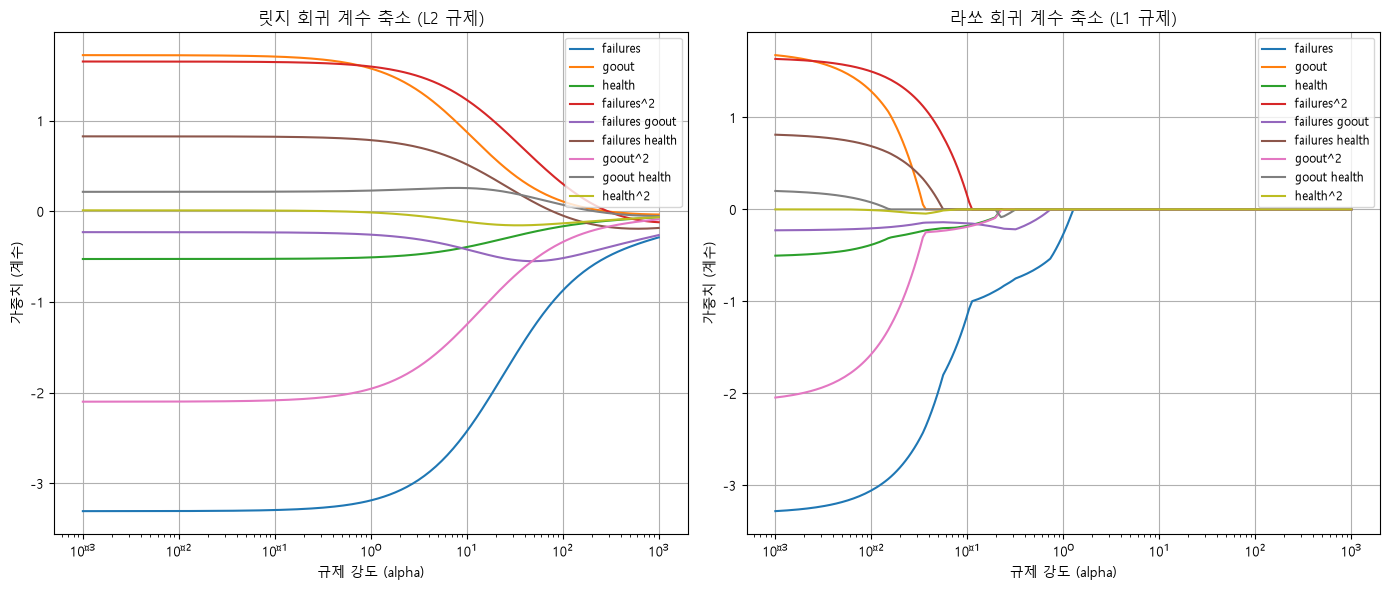

In [3]:
import numpy as np

alphas = np.logspace(-3, 3, 200)

ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_poly_scaled, y)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=alpha, max_iter=20000, tol=1e-4)
    lasso.fit(X_poly_scaled, y)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

feature_names = poly.get_feature_names_out(X.columns)
feature_names

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i in range(X_poly_scaled.shape[1]):
    axes[0].plot(alphas, ridge_coefs[:, i], label=feature_names[i])
axes[0].set_xscale('log')
axes[0].set_title('릿지 회귀 계수 축소 (L2 규제)')
axes[0].set_xlabel('규제 강도 (alpha)')
axes[0].set_ylabel('가중치 (계수)')
axes[0].grid(True)
axes[0].legend(fontsize='small', loc='upper right')

for i in range(X_poly_scaled.shape[1]):
    axes[1].plot(alphas, lasso_coefs[:, i], label=feature_names[i])
axes[1].set_xscale('log')
axes[1].set_title('라쏘 회귀 계수 축소 (L1 규제)')
axes[1].set_xlabel('규제 강도 (alpha)')
axes[1].set_ylabel('가중치 (계수)')
axes[1].grid(True)
axes[1].legend(fontsize='small', loc='upper right')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
df = pd.read_csv('Iris.csv')

df = df[(df['Species'] == "Iris-versicolor") | (df['Species'] == "Iris-virginica")]

X = df[['SepalLengthCm', 'SepalWidthCm']]
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression()

model.fit(X=X_train, y=y_train)

model_pred = model.predict(X_test)
model_accuracy = accuracy_score(y_test, model_pred)
print(f"정확도 : {model_accuracy:.4f}")

정확도 : 0.7000


In [5]:
from sklearn.model_selection import KFold, cross_val_score

X = df[['SepalLengthCm', 'SepalWidthCm']]
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression()

cv_scores = cross_val_score(model, X_train, y_train, cv=kf)

print("각 폴드별 정확도: ", cv_scores)
print("평균 검증 정확도: ", cv_scores.mean())

model.fit(X=X_train, y=y_train)
model_pred = model.predict(X_test)
model_accuracy = accuracy_score(y_test, model_pred)
print("최종 테스트 정확도:", model_accuracy)

각 폴드별 정확도:  [0.6875 0.625  0.6875 0.75   0.6875]
평균 검증 정확도:  0.6875
최종 테스트 정확도: 0.7


In [7]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

X_ex_train, X_ex_test, y_ex_train, y_ex_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_ex = LogisticRegression()
model_ex.fit(X=X_ex_train, y=y_ex_train)
model_ex_pred = model_ex.predict(X_ex_test)
model_ex_accuracy = accuracy_score(y_ex_test, model_ex_pred)
print("최종 테스트 정확도:", model_ex_accuracy)
print("최종 테스트 정확도:", model_accuracy)

최종 테스트 정확도: 0.9
최종 테스트 정확도: 0.7
